# Garment production

## Executive summary



## Introduction

## Library and data load

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.model_selection import KFold,StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
# load dataset
df = pd.read_csv('../datasets/garments_worker_productivity.csv')

## EDA

### Data types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

Meaning of features:

date: Date in MM-DD-YYYY.  
day: Day of the Week.  
quarter: A portion of the month. A month was divided into four quarters.  
department:	Associated department with the instance: sweing or finishing    
team_no: Associated team number with the instance.  
no_of_workers: Number of workers in each team.  
no_of_style_change:	Number of changes in the style of a particular product.  
targeted_productivity: Targeted productivity set by the Authority for each team for each day.  
smv: Standard Minute Value, it is the allocated time for a task.  
wip: Work in progress. Includes the number of unfinished items for products.  
over_time: Represents the amount of overtime by each team in minutes (as the sum of all their members).  
incentive: Represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action.  
idle_time: The amount of time during which the production was interrupted due to several reasons.  
idle_men: The number of workers who were idle due to production interruption.  
actual_productivity: The actual % of productivity that was delivered by the workers. It ranges from 0-1.  

### Data overview and cleanning

In [4]:
df.drop_duplicates()
df.head(20)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.755167
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428


In [5]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


There are some rows with a non-integer number of workers.

In [6]:
np.equal(df['no_of_workers']*2, np.round(df['no_of_workers']*2)).all()

np.True_

We verify that all non-integer 'no_of_workers' are x.5; We consider this like a part-time worker.

There are some strange values for 'actual_productivity' greater than 1.

In [7]:
df[df['actual_productivity']>1]

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
337,1/20/2015,Quarter3,finishing,Tuesday,5,0.70,4.15,NaN,1440,0,0.0,0,0,8.0,1.033570
437,1/26/2015,Quarter4,finishing,Monday,3,0.75,3.94,NaN,1800,0,0.0,0,0,10.0,1.059621
456,1/27/2015,Quarter4,sweing,Tuesday,2,0.75,22.52,1635.0,6840,119,0.0,0,0,57.0,1.000230
457,1/27/2015,Quarter4,sweing,Tuesday,3,0.75,22.52,1299.0,6840,119,0.0,0,0,57.0,1.000230
477,1/28/2015,Quarter4,sweing,Wednesday,2,0.80,22.52,1559.0,6840,90,0.0,0,0,57.0,1.000230
478,1/28/2015,Quarter4,sweing,Wednesday,3,0.80,22.52,1350.0,6840,113,0.0,0,0,57.0,1.000230
498,1/29/2015,Quarter5,sweing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
518,1/31/2015,Quarter5,sweing,Saturday,3,0.80,22.52,1136.0,6960,113,0.0,0,0,58.0,1.000457
519,1/31/2015,Quarter5,sweing,Saturday,2,0.80,22.52,1397.0,6840,113,0.0,0,0,57.0,1.000230
542,2/1/2015,Quarter1,finishing,Sunday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,1.011562


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
print(df['date'].value_counts())
print(df['date'].nunique())

date
2015-03-11    24
2015-01-31    24
2015-01-11    23
2015-03-10    23
2015-01-12    23
2015-01-24    23
2015-01-08    22
2015-01-10    22
2015-01-07    22
2015-01-13    22
2015-01-05    22
2015-03-09    22
2015-03-08    22
2015-03-03    22
2015-01-22    22
2015-02-25    21
2015-02-26    21
2015-02-28    21
2015-01-03    21
2015-01-04    21
2015-01-28    21
2015-01-27    21
2015-03-04    21
2015-01-25    21
2015-01-17    21
2015-01-14    21
2015-01-06    21
2015-02-18    21
2015-01-29    20
2015-02-17    20
2015-03-02    20
2015-03-01    20
2015-02-22    20
2015-02-19    20
2015-03-05    19
2015-03-07    19
2015-02-24    19
2015-02-23    19
2015-01-01    19
2015-02-03    19
2015-02-15    19
2015-01-15    19
2015-01-18    19
2015-01-19    19
2015-01-21    19
2015-01-26    19
2015-02-01    19
2015-02-02    19
2015-02-04    19
2015-02-07    19
2015-02-08    19
2015-02-10    19
2015-02-11    19
2015-02-12    19
2015-02-05    18
2015-02-09    18
2015-02-16    18
2015-02-14    17
2015-01-2

### Missing values

From describe we can see that the only missing values are in the feature wip, and these missings are only for department 'finishing'.

In [10]:
df[df['wip'].isna()].sort_values(by='department')

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
1196,2015-03-11,Quarter2,finishing,Wednesday,6,0.70,2.90,NaN,720,0,0.0,0,0,6.0,0.394722
838,2015-02-18,Quarter3,finishing,Wednesday,8,0.70,5.13,NaN,960,0,0.0,0,0,8.0,0.580000
837,2015-02-18,Quarter3,finishing,Wednesday,10,0.80,3.94,NaN,960,0,0.0,0,0,8.0,0.640250
836,2015-02-18,Quarter3,finishing,Wednesday,7,0.70,5.13,NaN,960,0,0.0,0,0,8.0,0.671875
833,2015-02-18,Quarter3,finishing,Wednesday,4,0.75,5.13,NaN,960,0,0.0,0,0,8.0,0.734646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,2015-01-22,Quarter4,finishing,Thursday,2,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
383,2015-01-22,Quarter4,finishing,Thursday,1,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
382,2015-01-22,Quarter4,finishing,Thursday,4,0.75,4.30,NaN,9000,0,0.0,0,0,15.0,0.670216
401,2015-01-24,Quarter4,finishing,Saturday,12,0.70,4.08,NaN,1620,0,0.0,0,0,9.0,0.858586


We can see that all the NaN in wip are related with department 'finising'.

And there aren't 'wip' 0. The 0 'wip' is pretty common in industry, so the absense of 'wip' is odd. We assume that the NaN values are those that should be 0.

In [11]:
df['wip']=df['wip'].fillna(0)

Let's obseve that the 'finishing' was not a daily task, in fact: in january just one team in one day worked in finishing

In [12]:
finishing_monthly = df[df['department'] == 'finishing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='finishing_count')

finishing_monthly

,date,finishing_count
0,2015-01-31,1
1,2015-02-28,151
2,2015-03-31,97


In [13]:
sweing_monthly = df[df['department'] == 'sweing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='sweing_count')

sweing_monthly

,date,sweing_count
0,2015-01-31,307
1,2015-02-28,269
2,2015-03-31,115


In [14]:
df['department'].value_counts()

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64

In [15]:
df['department'] = df['department'].str.strip()
df['department'].value_counts()

department
sweing       691
finishing    506
Name: count, dtype: int64

We introduce a ordinal categorical variable for actual productivity

In [16]:
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.9, float('inf')],
    labels=[1, 2, 3],
    right=False
)

In [17]:
summary = df.groupby(
    ['team', 'day', 'prod_cat']
).size().reset_index(name='count')

summary['prop'] = summary.groupby(['team','day'])['count'] \
                         .transform(lambda x: x/x.sum())

C:\Users\gabri\AppData\Local\Temp\ipykernel_9080\1907546767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(


In [18]:
df['prod_cat'].value_counts()

prod_cat
2    629
1    365
3    203
Name: count, dtype: int64

### Plots

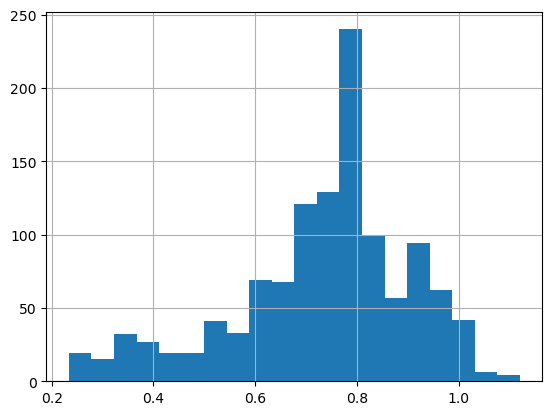

In [19]:
df['actual_productivity'].hist(bins=20);

In the productivity histogram, we can see a distribution center near 0.8. This value falls under our second productivity category, below the most desirable value.

<Axes: xlabel='department', ylabel='actual_productivity'>

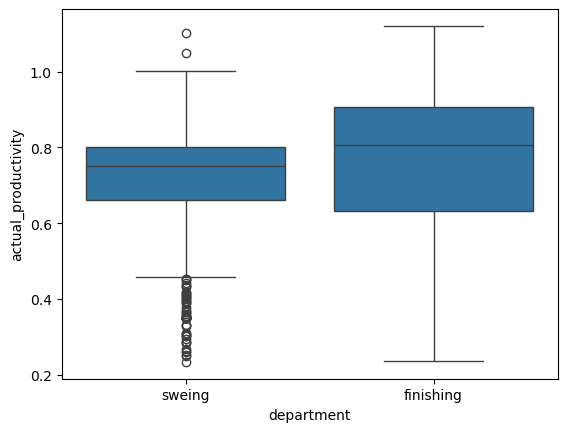

In [20]:
sns.boxplot(data=df, x='department', y='actual_productivity')

There is no significant difference between the actual productivity of sewing and finishing. It is worth mentioning the more homogeneous distribution in finishing, which is evident in the short distance between quartiles compared to the outliers present in sewing.

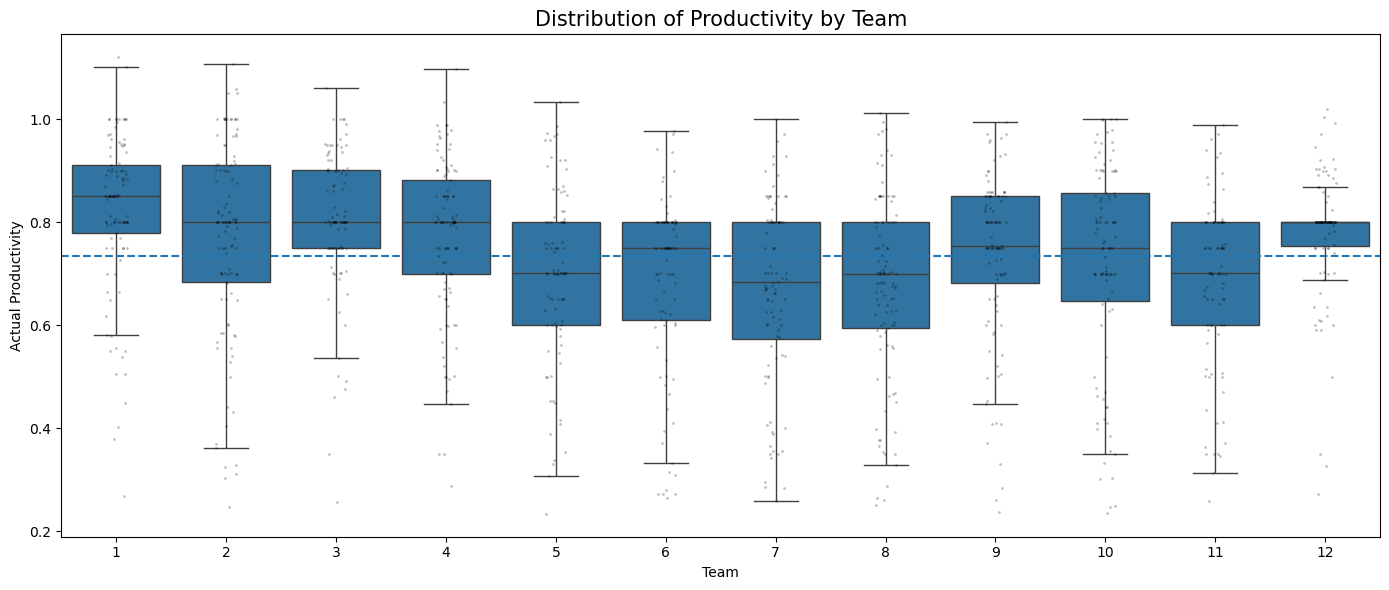

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='team',
    y='actual_productivity',
    showfliers=False
)

sns.stripplot(
    data=df,
    x='team',
    y='actual_productivity',
    color='black',
    alpha=0.25,
    size=2
)

# Línea de media global
global_mean = df['actual_productivity'].mean()
plt.axhline(global_mean, linestyle='--')

plt.title('Distribution of Productivity by Team', fontsize=15)
plt.xlabel('Team')
plt.ylabel('Actual Productivity')
plt.tight_layout()
plt.show()

In these boxplots, we can see that several teams have their mean productivity above the overall average, but all teams show a large IQR and several outliers.

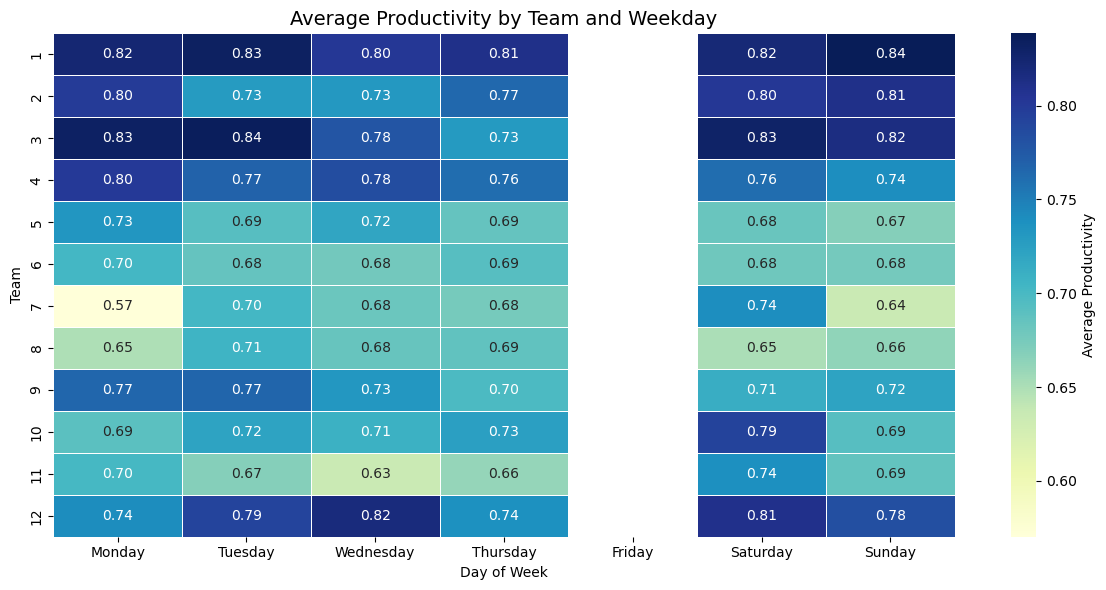

In [22]:
# Orden correcto de días
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Asegurar orden
df['day'] = pd.Categorical(df['day'],
                           categories=order_days,
                           ordered=True)

# Pivot ordenado
pivot = (
    df.groupby(['team','day'], observed=True)['actual_productivity']
      .mean()
      .unstack()
      .reindex(columns=order_days)
)

# Plot
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=True,        # muestra valores
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Average Productivity'}
)

plt.title('Average Productivity by Team and Weekday', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

This heatmap is another way to view the information already shown in the boxplots.

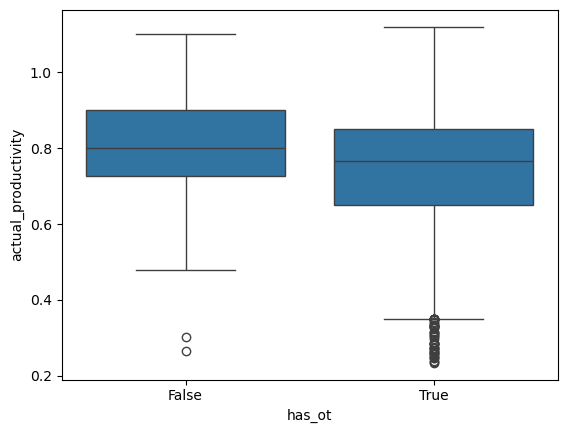

In [23]:
df['has_ot'] = df['over_time'] > 0

sns.boxplot(data=df,
            x='has_ot',
            y='actual_productivity');

The boxplots show that overtime does not lead to an increase in productivity.

C:\Users\gabri\AppData\Local\Temp\ipykernel_9080\1134042218.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Category')


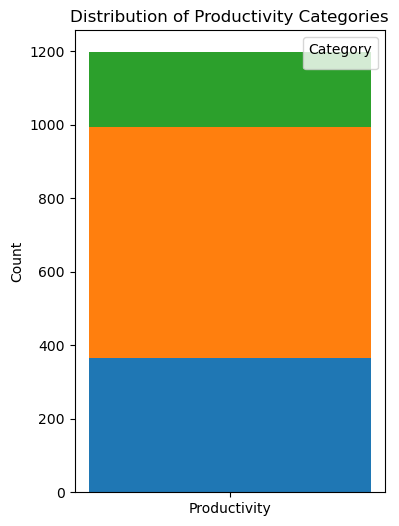

In [24]:
import matplotlib.pyplot as plt

counts = df['prod_cat'].value_counts().sort_index()

plt.figure(figsize=(4,6))

bottom = 0
for cat, value in counts.items():
    plt.bar('Productivity', value, bottom=bottom)
    bottom += value
    
plt.legend(title='Category')
plt.ylabel('Count')
plt.title('Distribution of Productivity Categories')
plt.show()

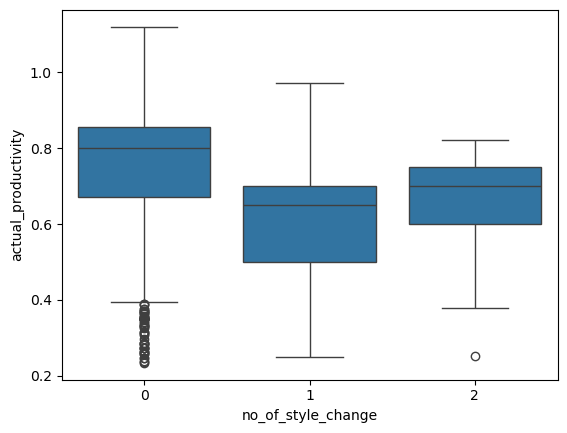

In [25]:
sns.boxplot(data=df, x='no_of_style_change', y='actual_productivity');

By the boxplots of actual productivity grouped by number of style changes, we can see that the style changes have no strong linear relation with productivity

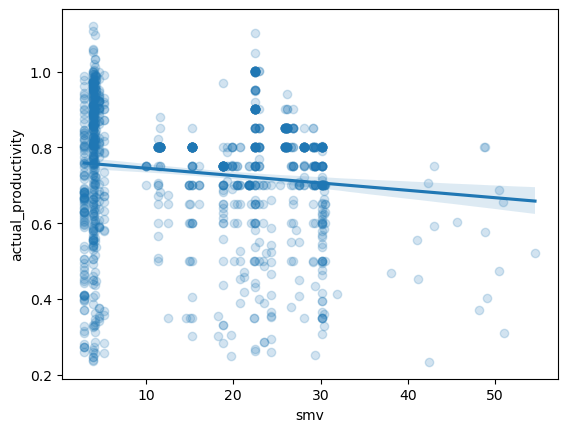

In [26]:
sns.regplot(data=df, x='smv', y='actual_productivity',
            scatter_kws={'alpha':0.2});

From the plot, we can see that there are typical SMV values instead of a continuous distribution.
The high heterogeneity in productivity shows that SMV is not enough to explain productivity, although it seems to have a negative correlation.

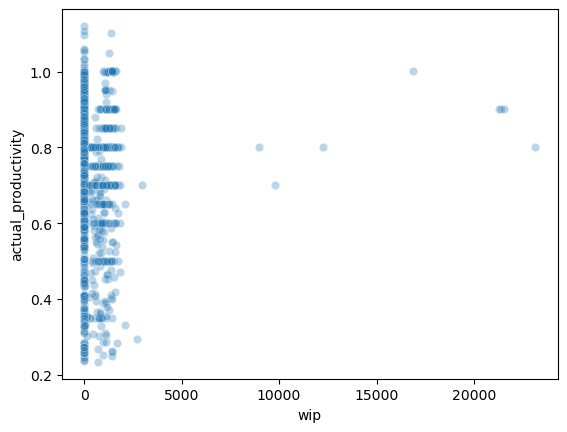

In [27]:
sns.scatterplot(data=df, x='wip', y='actual_productivity', alpha=0.3);

We apply a logarithmic scale for impove visualization.

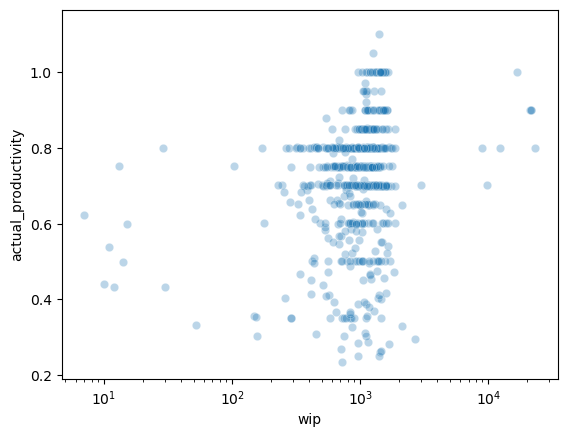

In [28]:
sns.scatterplot(data=df, x='wip', y='actual_productivity', alpha=0.3)
plt.xscale('log')

The distribution shows a slight positive association with productivity.
However, the relationship appears weak and the high dispersion suggests that WIP alone is not sufficient to explain productivity differences.

<Axes: xlabel='incentive', ylabel='actual_productivity'>

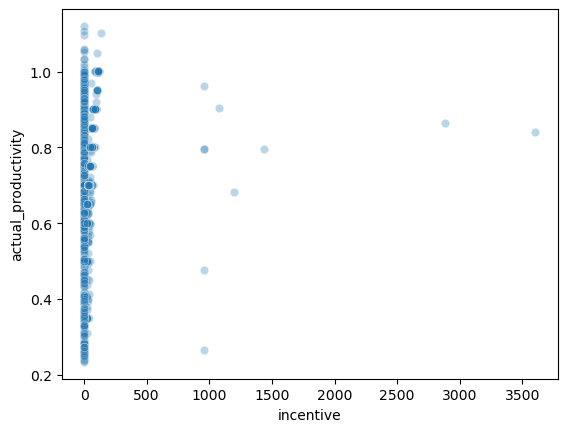

In [29]:
sns.scatterplot(data=df, x='incentive', y='actual_productivity', alpha=0.3)

We apply a logarithmic scale for impove visualization.

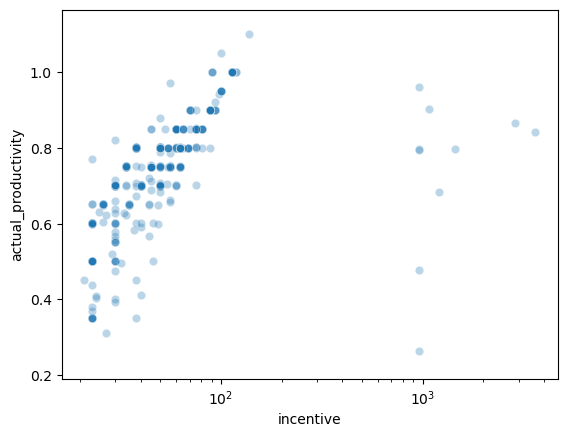

In [30]:
sns.scatterplot(data=df, x='incentive', y='actual_productivity', alpha=0.3)
plt.xscale('log')

If we discard incentive values greater than 500, we can see a fairly linear relationship between actual productivity and the logarithm of incentive.

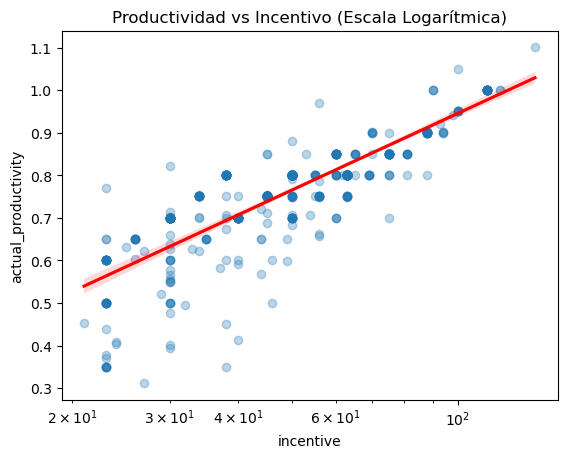

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtramos los datos (y <= 6 e incentivo > 0 para evitar errores de log)
df_clean = df[(df['incentive'] <= 500) & (df['incentive'] > 0)].copy()

# 2. Graficamos
# logx=True le dice a Seaborn que calcule la regresión sobre el logaritmo de X
sns.regplot(data=df_clean, x='incentive', y='actual_productivity', 
            logx=True, 
            scatter_kws={'alpha': 0.3}, 
            line_kws={'color': 'red'})

# 3. Cambiamos la escala del eje X a logarítmica para que la línea se vea recta
plt.xscale('log')

plt.title("Productividad vs Incentivo (Escala Logarítmica)")
plt.show()

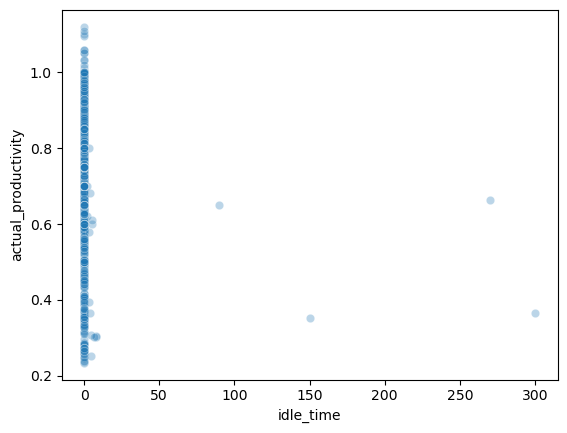

In [32]:
sns.scatterplot(data=df, x='idle_time', y='actual_productivity', alpha=0.3);

We apply a logarithmic scale for impove visualization.

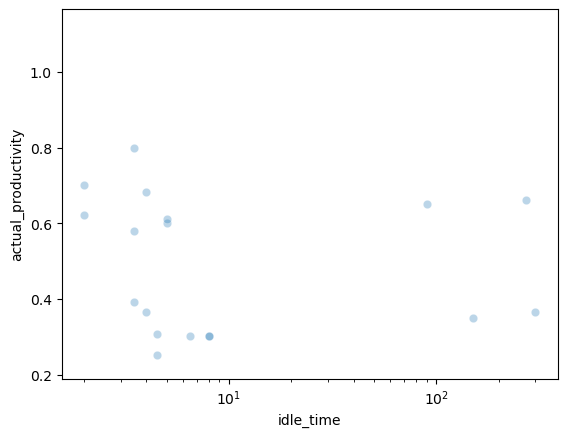

In [33]:
sns.scatterplot(data=df, x='idle_time', y='actual_productivity', alpha=0.3)

plt.xscale('log')

Whether using a logarithmic scale or not, the relationship remains unclear.

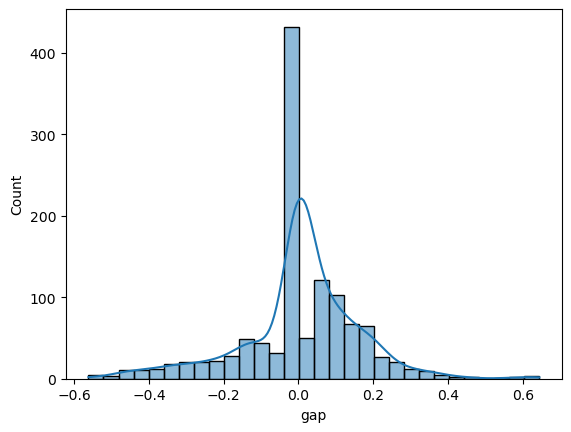

In [34]:
df['gap'] = df['actual_productivity'] - df['targeted_productivity']

sns.histplot(df['gap'],kde=True, bins=30);

The distribution of the productivity gap is approximately centered around zero, suggesting that, on average, actual productivity aligns with the targeted levels. Although slight asymmetry may be present, there is no strong evidence of systematic overestimation or underestimation in the targets.

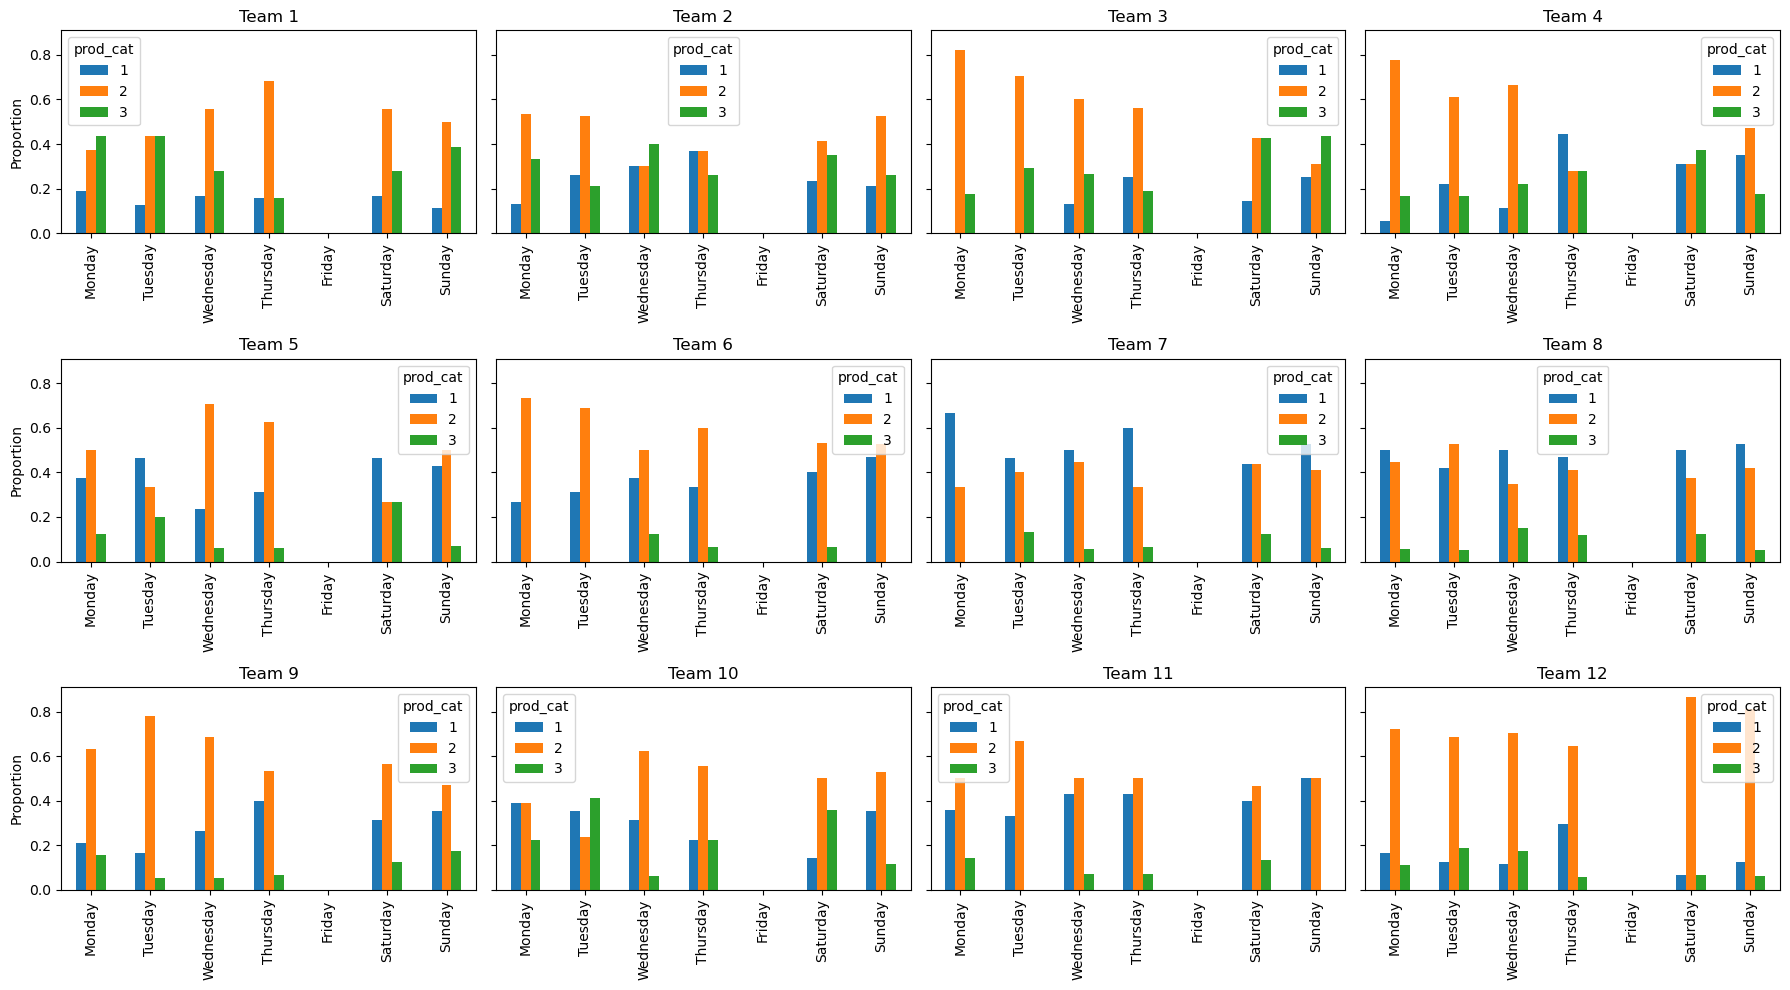

In [35]:
import matplotlib.pyplot as plt

teams = sorted(df['team'].unique())
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, t in enumerate(teams):
    
    ax = axes[i]
    
    aux = summary[summary['team']==t]
    
    pivot = aux.pivot(index='day', columns='prod_cat', values='prop')
    
    pivot = pivot.reindex(order_days)
    
    pivot.plot(kind='bar', ax=ax)
    
    ax.set_title(f'Team {t}')
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

It's clear that most of teams has a productivity 2 as mayoritary output and some teams (5, 6, 7, 8, 9, 11) has more productivity 1 than 3 (which means: worst productivity)

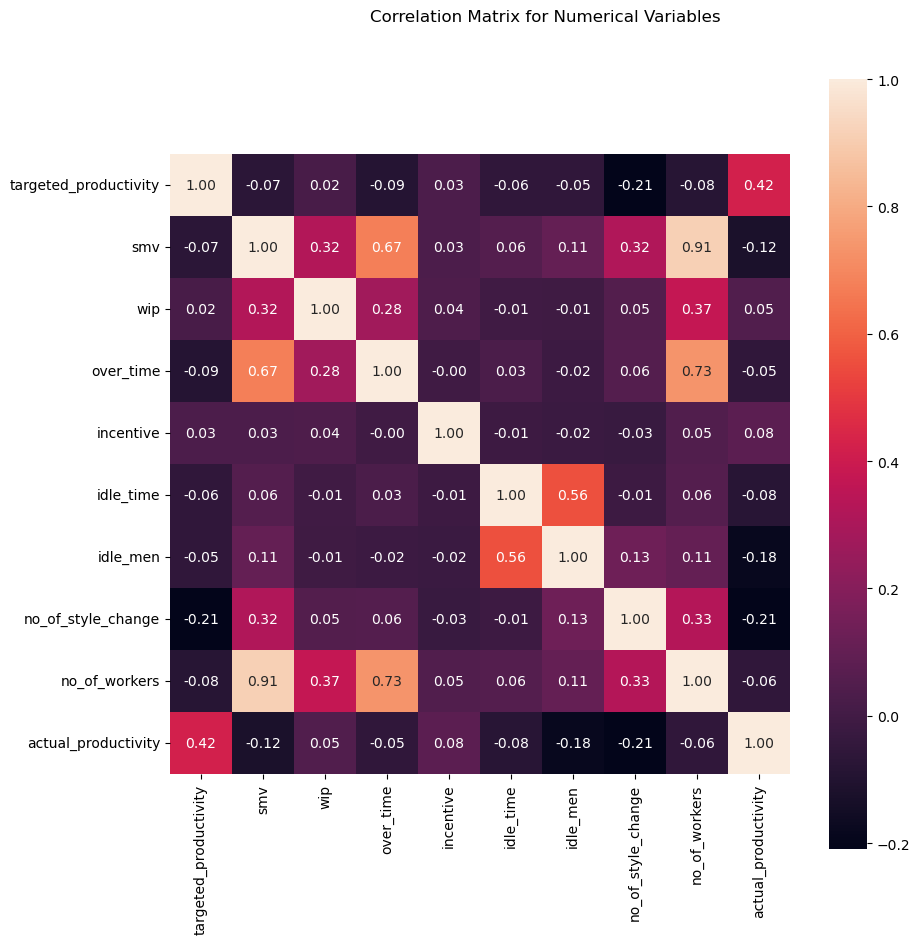

In [36]:

numerical_cols = ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']
correlation_matrix = df[numerical_cols].corr()

fig = plt.figure(figsize=(10, 10))
fig.suptitle('Correlation Matrix for Numerical Variables',  y=0.95)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",  square=True)

plt.show()

This shows, again, a positive correlation between actual and targeted productivity. A natural correlatio between idle men and idle time.
A very strong positivite correlation between number of workers and smv, and between number of workers and over_time. And, also, smv and over-time shown significative positive correlation.


### EDA summary

Number of days: 59

Number of teams: 12

Number of registers: 1197

Missing values: 0 (there were 506 NaN assumed as 0).

Production distribution by category:
Low (under 70%): 365  
Middle (between 70 and 90%): 629  
High (above 90%): 203  


Categorical features: 5 (department, day, team, quarter, date)

Numerical features: 10 (targeted_productivity, smv, wip, over_time, incentive, idle_time, idle_men, no_of_style_change, no_of_workers, actual_productivity)

Target: prod_cat, numerical ordinal.

Note 1: team is numerical, but its numerical value doesn't concern therefore, it is treated as categorical.
Note 2: actual_productivity must be removed for machine learning, because it will produce data leakage.

**Main observations:**
- The distribution of the gap between actual productivity and target productivity is approximately centered around zero, suggesting that, on average, actual productivity aligns with the targeted levels. Although slight asymmetry may be present, there is no strong evidence of systematic overestimation or underestimation in the targets. The leakage factor must be analyzed with this feature.
- If we discard incentive values greater than 500, we can see a fairly linear relationship between actual productivity and the logarithm of incentive..
- SMV is not enough to explain actual productivity, although it seems to have a negative correlation.
- Changes on the style appears not correlated with productivity changes.
- Over-time do not increase productivity
- Very strong positivite correlation between: number of workers and smv, and number of workers and over_time.
- Significative positive correlation between smv and over-time.


## Machine Learning

In [37]:
# load dataset
df = pd.read_csv('../datasets/garments_worker_productivity.csv')
df['date'] = pd.to_datetime(df['date'])
df['wip']=df['wip'].fillna(0)
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[1, 2, 3, 4],
    right=False
)

In [38]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate,GridSearchCV,HalvingGridSearchCV
import pandas as pd

# Define target
target = 'prod_cat'

# Define categorical columns
categorical_cols = [
    'department', 'day'#, 'team', 'quarter'
]

# Define numerical columns
numeric_cols = ['targeted_productivity',
                'smv', 'wip', 'over_time', 
                'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 
                'no_of_workers']

# separe features and target
X = df[categorical_cols + numeric_cols]
y = df[target]


We modify the labels because XGBost needs labels begining in 0

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

We define the models and preprocessor

In [40]:
# define models with usual parameters
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=43),
    "XGBoost": XGBClassifier(
         objective="multi:softmax",   # importante para multiclase
        num_class=4,                 # ajusta según tu problema
        eval_metric="mlogloss",
        random_state = 43,
        n_estimators = 300,
        learning_rate = 0.1,
        max_depth = 6
    )
}
# preprocesor pipeline
numeric_transformer = Pipeline([('scaler', StandardScaler())])
# encode for categorical variables
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
# combination of preprocessors
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols),
                                               ('cat', categorical_transformer, categorical_cols)])




We have a very desbalanced dataset, therefore we will we use stratified work with smote

In [41]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43) # This makes a crossvalidation stratified, considering the unbalanced chrun

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=43, 
    stratify=y
)

In [42]:
smote = SMOTE(
    sampling_strategy='auto',  # sobre-muestrea todas excepto la mayoritaria
    random_state=43,
    k_neighbors=5
)

#smote = SMOTE(
#    sampling_strategy={2: 300, 3: 300},
#    random_state=43
#)


metrics = {
    'F1': 'f1_macro',
    'BalAcc': 'balanced_accuracy',
    'MAE': 'neg_mean_absolute_error',
}

results_table = []

for name, model in models.items():
    print(f"Evaluando {name} con SMOTE...")
    
    pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', smote),      
        ('model', model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=skf,
        scoring=metrics,
        n_jobs=-1
    )
    
    results_table.append({
        'Model': name,
        'F1': scores['test_F1'].mean(),
        'BalAcc': scores['test_BalAcc'].mean(),
        'MAE': -scores['test_MAE'].mean(),
    })

df_results_smote = pd.DataFrame(results_table)
print(df_results_smote)

Evaluando LogReg con SMOTE...
Evaluando SVC con SMOTE...
Evaluando RandomForest con SMOTE...
Evaluando XGBoost con SMOTE...
          Model        F1    BalAcc       MAE
0        LogReg  0.520347  0.528790  0.750392
1           SVC  0.622064  0.640543  0.687012
2  RandomForest  0.694282  0.696472  0.433690
3       XGBoost  0.675730  0.677793  0.457656


Some words about this metrics:  
F1 macro: this is the average of applying F1 to each class; F1-Score is a combination of precission and recall, that is: grow up with good classified and penalize bad classified. For this metric, higher values are better.  
Balanced accuracy: The average proportion of correctly identified instances within each class. For this metric, higher values are better.  
MAE: is an average of the distance between the predicted and the actual class of each prediction. For this metric, lower values are better.

Therefore, the best model is Random forest

In [43]:
# Set the pipeline with the selected model
pipe_final =ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)), # SMOTE aquí se aplica bien
    ('model', XGBClassifier(
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        random_state=43
    ))
])
pipe_final =ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)), # SMOTE aquí se aplica bien
    ('model', RandomForestClassifier(random_state=43))
])



# set the grid of parameter values
param_distributions = {
    "model__n_estimators": [300, 600, 900],
    #"model__n_estimators": [300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7, 9],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__gamma": [0, 0.5, 1, 3],
    #"model__gamma": [0]
}
# Set the search by better roc_auc
param_distributions = {
    "model__n_estimators": [100, 200, 500, 800],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ['sqrt', 'log2', None],
    "model__bootstrap": [True, False],
    "model__class_weight": ['balanced', 'balanced_subsample', None]
}

search = RandomizedSearchCV(pipe_final, 
                            param_distributions = param_distributions, 
                            n_iter = 25, 
                            cv = skf, # the crosvalidation stratified
                            scoring = 'neg_mean_absolute_error',
                            random_state=43,
                            n_jobs=-1)


search.fit(X_train, y_train)

print(f"Best MAE after tuning: {-search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Best MAE after tuning: 0.4265
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 30, 'model__class_weight': 'balanced_subsample', 'model__bootstrap': False}


In [44]:
from sklearn.metrics import balanced_accuracy_score
best_model = search.best_estimator_
y_pred=best_model.predict(X_test)
print(f"F1-score after tuning: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Balanced accuracy after tuning: {balanced_accuracy_score(y_test, y_pred):.4f}")

F1-score after tuning: 0.7230
Balanced accuracy after tuning: 0.7276


Despite the parameters were tuning for MAE, we keep good values for the other metrics.

We observe a bias of errors of our model: we have more productivity miss-classified in a lower class than missclasified in a higher class.

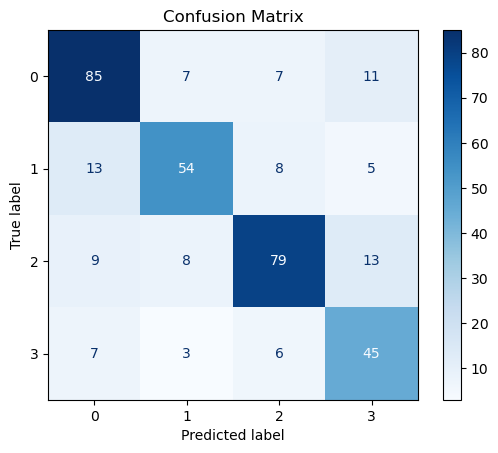

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


This bias is probably due to the metric and the unbalanced categories. For a dummy classifier with MAE, always returning 2 is a good strategy: it never incurs the highest penalization and, in most cases, either guesses the result or incurs the lowest penalization.

For this reason, we make a new tuning of the model using F1-macro

In this case, the MAE is slighly worst, the balanced accuracy is the same but the F1-macro was improved.

### Model Results and Evaluation

Using our best model and parameters we analize the results obtained, comparing actual productivity and predicter productivity.

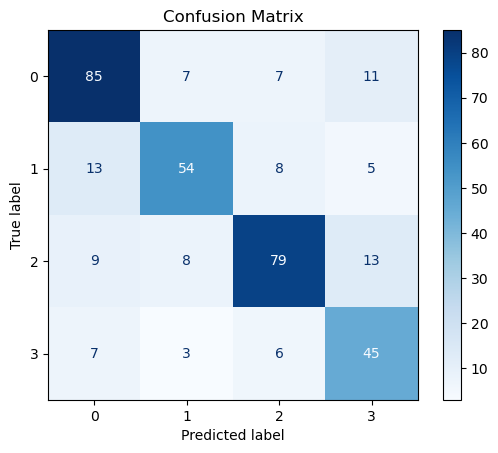

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

We observe that remain a bias to predict low categories but less than the previous training. Now, we consider this errors in proportion of categories

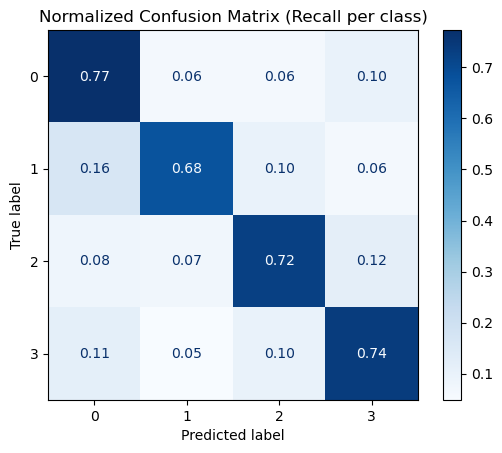

In [47]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix (Recall per class)")
plt.show()

We can see that every category has more correct labeled than incorrect labels.

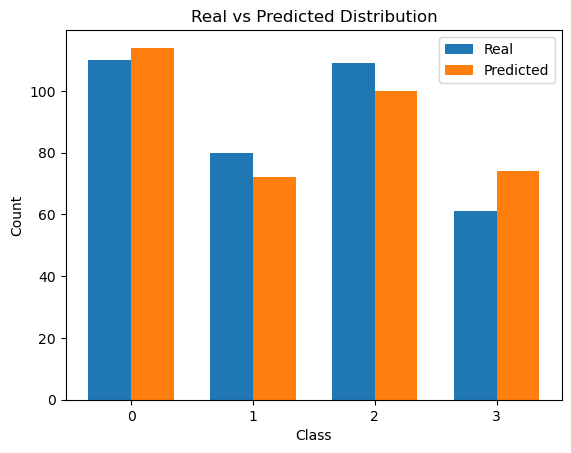

In [48]:
import numpy as np

classes = np.unique(y_test)

real_counts = [np.sum(y_test == c) for c in classes]
pred_counts = [np.sum(y_pred == c) for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure()
plt.bar(x - width/2, real_counts, width, label="Real")
plt.bar(x + width/2, pred_counts, width, label="Predicted")

plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Real vs Predicted Distribution")
plt.legend()
plt.show()

We can see that the middle categories has less prediction than actual values.

Analyzing the distance between predicted and actual labels reveals a decreasing frequency, which is a positive indicator for the model's performance.

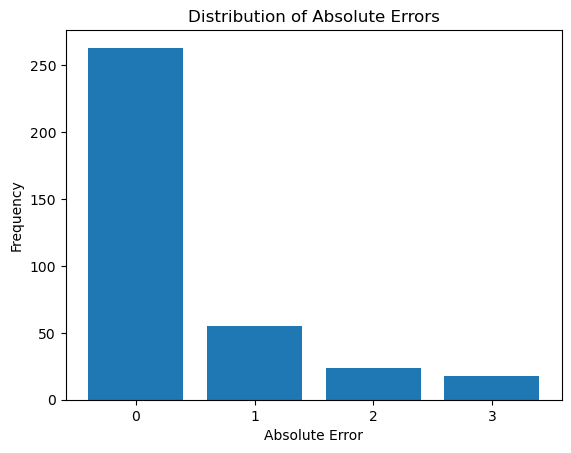

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

abs_errors = np.abs(y_test - y_pred)

# Valores únicos posibles (0,1,2,3,...)
error_values = np.arange(abs_errors.max() + 1)

# Contar frecuencia de cada error
counts = [np.sum(abs_errors == i) for i in error_values]

plt.figure()
plt.bar(error_values, counts)
plt.xticks(error_values)  # ticks enteros
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Errors")
plt.show()


Finally, we analize the feature importance

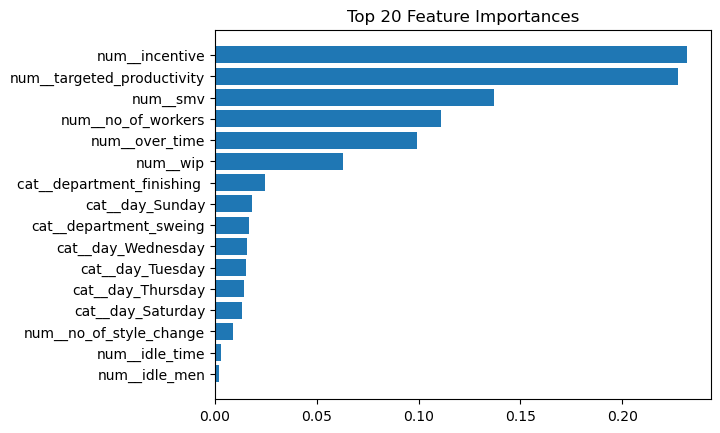

In [50]:
import pandas as pd

final_model = best_model.named_steps["model"]

importances = final_model.feature_importances_
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Top 10
top20 = feat_imp.head(20)

plt.figure()
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

Here we can see that the department is the main feature: note that sewing and finishing are mutually exclusive and collectively exhaustive.

On the other hand, incentive, number of workers and targeted productivity are numerical features with relevance. Meanwhile, smv, wip, overtime and idle have less relevance than expected.

We analize the impact of each of them

We will use SHAP. SHAP builds on Shapley values from cooperative game theory, which provide a mathematically principled way to distribute “credit” among players in a game. In our problem, the “game” is making the prediction, and the “players” are the features. Each feature gets credit based on its marginal contribution across all possible combinations of features.

We show that in some examples

In [52]:
import shap
# --- 1. Obtener modelo y preprocesador ---
final_model = best_model.named_steps['model']
preprocessor = best_model.named_steps["preprocess"]

# --- 2. Transformar datos ---
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Nombres de las features transformadas
feature_names = preprocessor.get_feature_names_out()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# --- 3. Crear EXPLAINER con fondo de ENTRENAMIENTO (muestra para eficiencia) ---
background = shap.sample(X_train_transformed_df, 100)  # 100 muestras aleatorias
explainer = shap.Explainer(final_model, background)

# --- 4. Calcular SHAP values sobre TEST (para explicar predicciones nuevas) ---
print("Calculando SHAP values sobre test...")
shap_values = explainer.shap_values(X_test_transformed_df, approximate=True)

# --- 5. Verificar el formato de shap_values ---
print(f"Tipo de shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"  Es lista con {len(shap_values)} elementos")
    for i, sv in enumerate(shap_values):
        print(f"  shap_values[{i}].shape = {sv.shape}")
else:
    print(f"  shap_values.shape = {shap_values.shape}")

# --- 6. Normalizar a una lista de arrays (una por clase) ---
# Dependiendo del modelo, shap_values puede ser:
# - Lista de (n_samples, n_features) para cada clase → queremos mantener la lista
# - Array 3D de (n_samples, n_features, n_classes) → convertir a lista

if isinstance(shap_values, list):
    # Ya es una lista de arrays por clase
    shap_list = shap_values
    print(f"Formato lista detectado: {len(shap_list)} clases")
else:
    # Array 3D: asumimos (n_samples, n_features, n_classes)
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    print(f"Formato 3D detectado: {shap_values.shape} -> lista de {len(shap_list)} arrays")

# Verificar que el número de clases coincida
n_classes = len(shap_list)
print(f"Número de clases según SHAP: {n_classes}")

Calculando SHAP values sobre test...
Tipo de shap_values: <class 'numpy.ndarray'>
  shap_values.shape = (360, 16, 4)
Formato 3D detectado: (360, 16, 4) -> lista de 4 arrays
Número de clases según SHAP: 4


In [53]:
# import shap



# final_model = best_model.named_steps['model'] 
# preprocessor = best_model.named_steps["preprocess"]
# print(X_train.index)
# # Transformar X_train con el preprocesador
# X_test_transformed = preprocessor.transform(X_test)
# X_train_transformed = preprocessor.transform(X_train)
# X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
# X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# explainer = shap.Explainer(final_model,X_test_transformed_df)

# feature_names = preprocessor.get_feature_names_out()
# # Convertir a DataFrame para que SHAP muestre nombres

# print(X_test_transformed_df.index)
# # Calculate SHAP values for our test set
# print("Calculating SHAP values...")
# shap_values = explainer.shap_values(X_train_transformed_df,approximate=True)
 
# # print(f"SHAP values calculated for {shap_values.shape[0]} predictions")
# # print(f"Each prediction explained by {shap_values.shape[1]} features")
 
# # # The base value (expected value) - what the model predicts on "average"
# # # Quick verification: SHAP values should be additive
# # sample_idx = 0
# # model_pred = final_model.predict(X_test.iloc[[sample_idx]])[0]
# # shap_sum = explainer.expected_value + np.sum(shap_values[sample_idx])
# # print(f"Verification - Model prediction: ${model_pred:,.2f}")
# # print(f"Verification - SHAP sum: 𝑠⁢ℎ⁡𝑎⁢𝑝𝑠⁢𝑢⁢𝑚:,.2⁢𝑓(𝑑⁢𝑖⁢𝑓⁡𝑓⁡𝑒⁢𝑟⁢𝑒⁢𝑛⁢𝑐⁢𝑒 :{abs(model_pred - shap_sum):.2f})")

In [54]:
# X_test_transformed = preprocessor.transform(X_test)
# print(X_test.index)
# explainer = shap.Explainer(final_model,X_test_transformed)

# feature_names = preprocessor.get_feature_names_out()
# # Convertir a DataFrame para que SHAP muestre nombres
# X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
# print(X_test_transformed_df.index)

In [55]:
# # ─── Normalizar shap_values a lista de arrays 2D (una por clase) ───────────
# raw = np.array(shap_values)


# if raw.ndim == 3:
#     # Formato nuevo: (n_samples, n_features, n_classes) → lista de (n_samples, n_features)
#     shap_list = [raw[:, :, i] for i in range(raw.shape[2])]
#     print(f"Formato 3D detectado → {raw.shape}  →  {len(shap_list)} arrays de {shap_list[0].shape}")

# elif raw.ndim == 4:
#     # Algunos RF devuelven (n_classes, n_samples, n_features, 1)
#     shap_list = [raw[i, :, :, 0] for i in range(raw.shape[0])]
#     print(f"Formato 4D detectado → {raw.shape}")

# else:
#     # Formato clásico: ya es lista de (n_samples, n_features)
#     shap_list = list(shap_values)
#     print(f"Formato clásico (lista) → {len(shap_list)} arrays de {shap_list[0].shape}")

# # Verificación
# n_features_data = X_train_transformed_df.shape[1]
# n_features_shap = shap_list[0].shape[1]
# assert n_features_data == n_features_shap, \
#     f"Aún hay mismatch: datos={n_features_data}, shap={n_features_shap}"
# print("✅ Shapes alineados")

We analize the sample number 1 of our test set, for this sample the features and prediction are:

In [56]:
# --- 7. Seleccionar una muestra de TEST para explicar ---
sample_idx = 1  # Índice dentro de X_test (puedes cambiarlo)

# Obtener la predicción real del modelo sobre esa muestra
sample_test_transformed = X_test_transformed_df.iloc[[sample_idx]]
pred_class = final_model.predict(sample_test_transformed)[0]
pred_proba = final_model.predict_proba(sample_test_transformed)[0]

print(f"\n--- Muestra {sample_idx} (TEST) ---")
print(f"Predicción del modelo: clase {pred_class}")
print(f"Probabilidades: {pred_proba}")
print(X_test.iloc[sample_idx])


--- Muestra 1 (TEST) ---
Predicción del modelo: clase 3
Probabilidades: [9.73451327e-05 2.01489072e-03 2.74220589e-02 9.70465705e-01]
department                sweing
day                      Tuesday
targeted_productivity        0.8
smv                        22.52
wip                       1112.0
over_time                   6840
incentive                    100
idle_time                    0.0
idle_men                       0
no_of_style_change             0
no_of_workers               57.0
Name: 585, dtype: object


C:\Users\gabri\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\gabri\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [57]:
# sample_idx = 1
# print(X_test.iloc[sample_idx])
# print("Predicted class:", y_test[sample_idx])

The next plot shows that, by default, each sample has a probability of being classified in each category (shown as $E[f(x)]$). The value of each feature pushes the probability up or down, according to the arrow. The color of the arrow indicates if the present value of the features is high (red) or down (blue) with respect to the dataset.

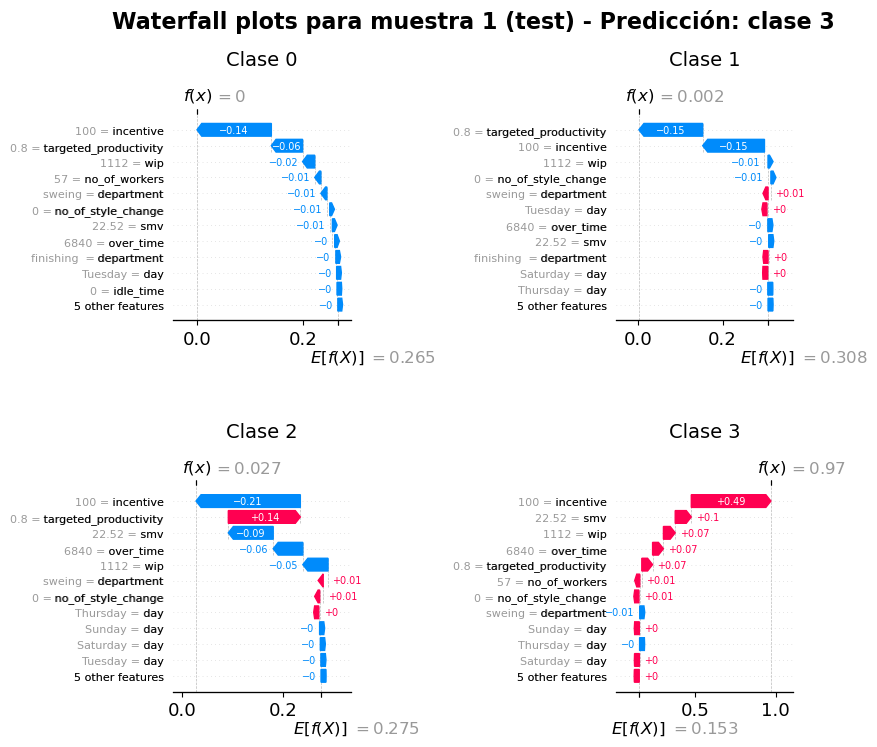

In [66]:

# --- 8. Preparar datos para visualización (opcional: mapear a nombres originales) ---
# Asumimos que X_test (sin transformar) tiene los nombres originales
sample_original = X_test.iloc[sample_idx]

# Crear array de display: para cada feature transformada, 
# buscar el valor original correspondiente
display_data = []
display_names = []

for feat_name in feature_names:
    # Intentar extraer el nombre base (ej: "num__edad" → "edad", "cat__depto_A" → "depto")
    base_name = feat_name.split("__")[-1]          # quita prefijo num__ o cat__
    #base_name = base_name.split("_")[0]             # quita sufijo OHE si aplica
    
    if base_name in sample_original.index:
        display_data.append(sample_original[base_name])
        display_names.append(f"{base_name}")
    else:
        parts = base_name.split('_', 1)
        display_data.append(parts[1])
        display_names.append(f"{parts[0]}")  # fallback al nombre transformado


# --- 9. Graficar waterfall para cada clase ---
fig, axes = plt.subplots(2, 2, figsize=(25, 12))
axes = axes.flatten()

ev = explainer.expected_value  # array de valores base por clase

for i, ax in enumerate(axes):
    plt.sca(ax)
    
    # Crear objeto Explanation para la clase i
    exp = shap.Explanation(
        values=shap_list[i][sample_idx],        # SHAP values de la clase i para esta muestra
        base_values=ev[i] if hasattr(ev, '__len__') else ev,
        data=display_data,
        feature_names=display_names
    )
    
    # Waterfall plot (con max_display para no saturar)
    shap.plots.waterfall(exp, max_display=12, show=False)
    
    # Ajustes de formato
    ax.set_title(f"Clase {i}", fontsize=14, pad=15)
    ax.tick_params(axis='y', labelsize=8)
    for text in ax.texts:
        text.set_fontsize(7)

# 2. Ajustamos el espaciado entre subplots (wspace es el espacio horizontal)
plt.subplots_adjust(wspace=1.5, hspace=.8)
plt.suptitle(f"Waterfall plots para muestra {sample_idx} (test) - Predicción: clase {pred_class}",
             fontsize=16, fontweight='bold', y=1.02)
plt.show()


We observe that, a priori, the most probable class is 1 (beacuse of $E(F(x))=0.308$) but the prediction is obtaining summing this a priori probability with the effect of all the features. We analize the impact of most relevant features:
- 'incentive' is the feature with biggest feature importance, and has 100. By the arrows, we observe that this features push-up the proability for class 3 in 0.49 and push-down the probabilities of the rest of classes.
- 'targeted_productivity': push-up strongly class 2 and also to class 3. And pull-down class 0 and 1.
- 'smv': has positive impact por class 3 and negative for the rest of classes.
- 'no_of_workers': has relevance only for class 0, for this sample. And has negative impact.
- 'over_time': has low negative impact for class0 and low possitive impact for class 3.

After summing up all this effects we obtain that probability for class 3 is 0.97; for class 2 is 0.027; for class 1 is 0.002; and 0 for class 0. Therefore, the predicted class is 0.

In [ ]:
# import matplotlib.pyplot as plt
# import shap
# class_names = ['Clase 0', 'Clase 1', 'Clase 2', 'Clase 3']

# sample_original = X_test.iloc[sample_idx]  # fila original


# # 1. Aumentamos mucho el figsize, especialmente el ancho (width)
# fig, axes = plt.subplots(2, 2, figsize=(30, 15)) 
# axes = axes.flatten() #for easier iteration

# # Crear array de display: para cada feature transformada, 
# # buscar el valor original correspondiente
# display_data = []
# display_names = []

# for feat_name in feature_names:
#     # Intentar extraer el nombre base (ej: "num__edad" → "edad", "cat__depto_A" → "depto")
#     base_name = feat_name.split("__")[-1]          # quita prefijo num__ o cat__
#     #base_name = base_name.split("_")[0]             # quita sufijo OHE si aplica
    
#     if base_name in sample_original.index:
#         display_data.append(sample_original[base_name])
#         display_names.append(f"{base_name}")
#     else:
#         parts = base_name.split('_', 1)
#         display_data.append(parts[1])
#         display_names.append(f"{parts[0]}")  # fallback al nombre transformado

# # 2. Ajustamos el espaciado entre subplots (wspace es el espacio horizontal)
# plt.subplots_adjust(wspace=1.5, hspace=1.8)

# ev = explainer.expected_value
# for i, ax in enumerate(axes):
#     plt.sca(ax) # Definir eje actual
    
#     TARGET_CLASS = i
#     base_val = ev[TARGET_CLASS] if hasattr(ev, '__len__') else ev
    
#     exp = shap.Explanation(
#         values        = shap_list[TARGET_CLASS][sample_idx],
#         base_values   = base_val,        
#         feature_names = display_names, # Usamos la lista limpia
#         data          = display_data
#         #data          = X_test_df.iloc[sample_idx].values,
#         #feature_names = feature_names.tolist()
#     )
    
#     # 3. Usamos max_display para que el gráfico sea más compacto verticalmente
#     # 4. show=False es vital para que no resetee la figura
#     shap.plots.waterfall(exp, max_display=10, show=False)

#     labels = [item.get_text() for item in ax.get_yticklabels()]
#     ax.set_yticklabels(labels, fontsize=2)
    
#     for text in ax.texts:
#         text.set_fontsize(5) # fontsize for text in arrows
        
#     # Ajustamos el título y etiquetas para que no choquen
#     ax.set_title(f"Clase {i}", fontsize=16, pad=20)
#     ax.tick_params(axis='both', which='major', labelsize=10)

# # 5. No usamos tight_layout() si ya usamos subplots_adjust, 
# # a veces tight_layout colapsa los espacios que definimos manualmente.
# pred_class = final_model.predict(X_test_transformed_df.iloc[[sample_idx]].values)[0]
# plt.suptitle(f"Decision plots — muestra {sample_idx}  |  Predicción: {class_names[pred_class]}",
#              fontsize=14, fontweight='bold', y=1.05)
# plt.show()
# print(final_model.predict(X_test_transformed_df.iloc[[sample_idx]].values))

## Industrial implications

In the garment industry, by traditional methods, they calculate the expected productivity (in our dataset: targeted productivity). Our model also provides an expected productivity by class. In this section we compare the quality of both estimations using the classes determined for our machine learning model.

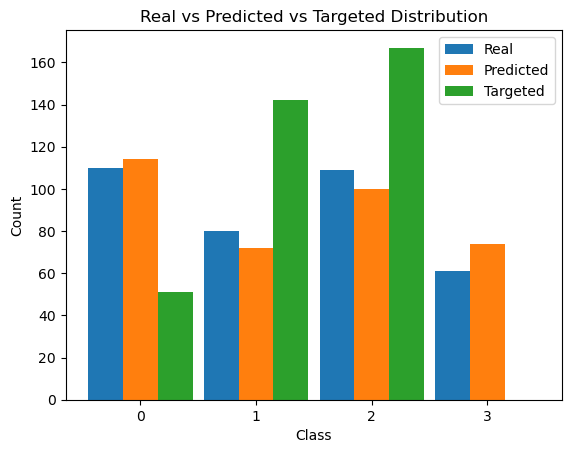

In [81]:
import numpy as np

classes = np.unique(y_test)

real_counts = [np.sum(y_test == c) for c in classes]
pred_counts = [np.sum(y_pred == c) for c in classes]
targ_counts = [np.sum(y_targeted == c) for c in classes]

x = np.arange(len(classes))
width = 0.3

plt.figure()
plt.bar(x - width, real_counts, width, label="Real")
plt.bar(x , pred_counts, width, label="Predicted")
plt.bar(x + width, targ_counts, width, label="Targeted")

plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Real vs Predicted vs Targeted Distribution")
plt.legend()
plt.show()

It is clear that our prediction is better than targeted distribution, for measuring that we count the disctance of eache prediction with the actual value. We count the frequency of each possible distance for the targeted and predicted productivity

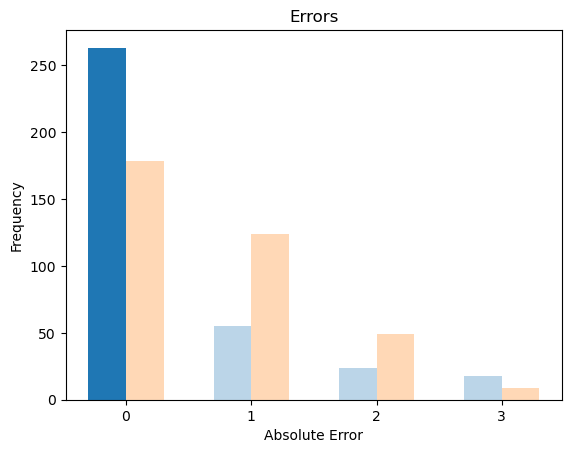

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error



abs_errors_pred = np.abs(y_test - y_pred)
abs_errors_targ = np.abs(y_test - y_targeted)

# Valores únicos posibles (0,1,2,3,...)
error_values = np.arange(abs_errors_pred.max() + 1)

# Contar frecuencia de cada error
counts_pred = [np.sum(abs_errors_pred == i) for i in error_values]
counts_targ = [np.sum(abs_errors_targ == i) for i in error_values]

fig, ax = plt.subplots()
width = 0.3
pred_bar = ax.bar(error_values- width/2, counts_pred,width, label="Errors in predicted")
targ_bar = ax.bar(error_values+ width/2, counts_targ,width, label="Errors in targeted")

opacity_faded = 0.3 

# Iterar sobre las barras de cada grupo para cambiar su opacidad
# Saltar la primera barra (índice 0) de cada grupo
for i, bar in enumerate(pred_bar):
    if i != 0:  # Si no es la primera barra (valor 0), la atenuamos
        bar.set_alpha(opacity_faded)
    
for bar in targ_bar:
    bar.set_alpha(opacity_faded)
    
plt.xticks(error_values)  # ticks enteros
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Errors")
plt.show()


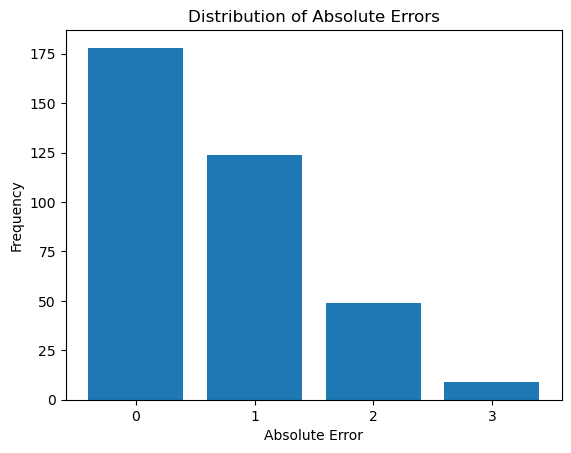

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

abs_errors = np.abs(y_test - y_targeted)

# Valores únicos posibles (0,1,2,3,...)
error_values = np.arange(abs_errors.max() + 1)

# Contar frecuencia de cada error
counts = [np.sum(abs_errors == i) for i in error_values]

plt.figure()
plt.bar(error_values, counts)
plt.xticks(error_values)  # ticks enteros
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Errors")
plt.show()
